# Conexión con LLMs

In [1]:
!pip install -q langchain langchain-google-genai google-generativeai

In [2]:
!pip install -q groq langchain-groq

In [3]:
from google.colab import userdata
import os

os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

In [4]:
# from google.colab import userdata
# GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
# NO ESTA ACTIVA

In [5]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=1
)

In [6]:
respuesta = llm.invoke("en cinco líneas, ¿Qué es negocio de e-commerce?")

In [7]:
respuesta.content

'Un negocio de e-commerce es una empresa que vende productos o servicios en línea.\nUtiliza internet y plataformas digitales para alcanzar a los clientes.\nPermite a los consumidores comprar desde cualquier lugar y en cualquier momento.\nEl pago y la entrega se realizan a través de canales electrónicos.\nEs un modelo de negocio que ha revolucionado la forma en que se compra y se vende en la actualidad.'

In [8]:
PROMPT_TRIAJE_ECOMMERCE = """
	Eres un especialista en triaje automatizado para el Service Desk de un E-commerce.
	Dado el mensaje del cliente, devuelve SÓLO un JSON con la siguiente estructura:\n
	{\n
	 "decision": "AUTO_RESOLVER" | "PEDIR_INFO" | "ABRIR_TICKET_LOGISTICA" | "ESCALAR_URGENTE",\n
	 "urgencia": "BAJA" | "MEDIANA" | "ALTA" | "CRITICA",\n
	 "categoria": "DEVOLUCIONES" | "ENVIOS" | "PAGOS_Y_FACTURACION" | "PRODUCTO_Y_STOCK" | "SOPORTE_TECNICO",\n
	 "campos_faltantes": ["numero_pedido", "correo_registro", "motivo_especifico"]
	}\n

	Reglas para 'decision' y 'urgencia':

	- **AUTO_RESOLVER** (Urgencia: BAJA o MEDIANA):\n
	  * Consultas generales sobre políticas de envío, tablas de talles, horarios o métodos de pago.\n
	  * Ejemplos: "¿Cuánto tarda el envío a mi zona?", "¿Tienen cuotas sin interés?", "¿Cuál es su política de cambios?".\n

	- **PEDIR_INFO** (Urgencia: BAJA):\n
	  * El mensaje del cliente es impreciso, no especifica el problema o le faltan datos críticos para poder revisar el sistema (como el número de orden).\n
	  * Ejemplos: "Mi pedido no llegó", "Quiero hacer un cambio", "Tuve un problema con el pago".\n
	  * Nota: Rellenar la lista 'campos_faltantes' con los datos que se necesitan para procesar la ayuda.\n

	- **ABRIR_TICKET_LOGISTICA** (Urgencia: MEDIANA o ALTA):\n
	  * Solicitudes explícitas de cancelación de órdenes que aún no se han despachado, cambios de dirección de entrega urgentes o reclamos de productos faltantes en el paquete.\n
	  * Ejemplos: "Me equivoqué de dirección y compré hace una hora, cambien la dirección a Calle Falsa 123, a dos casas del kiosko chiringuito", "Me llegó el paquete, pero falta el pantalón".\n

	- **ESCALAR_URGENTE** (Urgencia: ALTA o CRITICA):\n
	  * Casos de sospecha de fraude, pasarelas de pago caídas que cobran doble, productos que llegaron rotos/dañados, o retrasos logísticos graves con más de 5 días de demora prometida.\n
	  * Ejemplos: "Me cobraron dos veces la misma compra", "El perfume llegó roto y derramado", "Mi pedido tenía fecha para el lunes pasado y sigue en viaje".\n

	Analiza el mensaje del cliente, define la 'categoria' correspondiente y decide la acción más adecuada.
"""


In [9]:
from typing import Literal, List, Dict
from pydantic import BaseModel, Field

class TriajeOut(BaseModel):
  decision: Literal["AUTO_RESOLVER", "PEDIR_INFO", "ABRIR_TICKET_LOGISTICA", "ESCALAR_URGENTE"]
  urgencia: Literal["BAJA", "MEDIANA", "ALTA", "CRITICA"]
  categoria: Literal["DEVOLUCIONES", "ENVIOS", "PAGOS_Y_FACTURACION", "PRODUCTO_Y_STOCK", "SOPORTE_TECNICO"]
  campos_faltantes: List[str] = Field(default_factory=list)
  #campos_faltantes: ["numero_pedido", "correo_registro", "motivo_especifico"]

In [10]:
from langchain_core.messages import SystemMessage, HumanMessage

chain_de_triaje = llm.with_structured_output(TriajeOut)

def triaje(mensaje: str) -> Dict:
  salida: TriajeOut = chain_de_triaje.invoke(
      [
          SystemMessage(content=PROMPT_TRIAJE_ECOMMERCE),
          HumanMessage(content=mensaje)
      ]
  )
  return salida.model_dump()

In [11]:
import time
from langchain_core.messages import SystemMessage, HumanMessage
from typing import Dict

chain_de_triaje = llm.with_structured_output(TriajeOut)

def triaje(mensaje: str) -> Dict:
  salida: TriajeOut = chain_de_triaje.invoke(
      [
          SystemMessage(content=PROMPT_TRIAJE_ECOMMERCE),
          HumanMessage(content=mensaje)
      ]
  )
  return salida.model_dump()

mensajes_de_prueba = [
	"Hice una compra hace una semana para una dirección en zona urbana y el paquete todavía no me llegó, ¿dónde está?",
	"Me equivoqué al escribir la dirección de mi pedido, puse Calle Mexico 123 y era 1234, ¡ayuda antes de que lo envíen!",
	"Acabo de recibir mi paquete hace dos horas, viene todo aplastado por el correo y el producto adentro está roto.",
	"El teléfono se me cayó al suelo por accidente, se rompió la pantalla y no prende. ¿Me lo cubre la garantía?",
	"Hola, mi producto de BimBam Buy dejó de funcionar de la nada y quiero usar la garantía de fábrica.",
	"Compré una campera hace 5 días, pero me arrepentí, está sin usar y quiero que me devuelvan el dinero.",
	"Me acaba de llegar el paquete, pero me mandaron unas zapatillas negras en vez de las rojas que compré.",
	"El banco me cobró la compra en la tarjeta, pero no me llegó ningún correo de confirmación ni número de orden.",
	"Intenté comprar, pero el sistema me rechaza la tarjeta todo el tiempo, ¿qué puedo hacer?",
	"Revisé mi cuenta del banco y me aparece que me cobraron dos veces exactamente el mismo monto por mi pedido.",
	"Ya me aprobaron la devolución del dinero, ¿cuánto tiempo tarda en verse reflejado el reembolso?",
	"Hola, envié mi postulación para el programa de afiliados hace unos días y quería saber si ya me aprobaron la cuenta.",
	"¿Qué pasa con mi comisión si un usuario compró con mi enlace de afiliado, pero luego devolvió el producto?",
	"Me llegó una alerta diciendo que mi cuenta de afiliado está suspendida por publicar precios incorrectos, exijo una revisión.",
	"¿Quién es Zinedine Zidane?"
]

for pregunta in mensajes_de_prueba:
  r = triaje(pregunta)
  print(f"{pregunta} -> {r}")
  time.sleep(1)

Hice una compra hace una semana para una dirección en zona urbana y el paquete todavía no me llegó, ¿dónde está? -> {'decision': 'ABRIR_TICKET_LOGISTICA', 'urgencia': 'MEDIANA', 'categoria': 'ENVIOS', 'campos_faltantes': ['numero_pedido']}
Me equivoqué al escribir la dirección de mi pedido, puse Calle Mexico 123 y era 1234, ¡ayuda antes de que lo envíen! -> {'decision': 'ABRIR_TICKET_LOGISTICA', 'urgencia': 'ALTA', 'categoria': 'ENVIOS', 'campos_faltantes': ['numero_pedido']}
Acabo de recibir mi paquete hace dos horas, viene todo aplastado por el correo y el producto adentro está roto. -> {'decision': 'ESCALAR_URGENTE', 'urgencia': 'ALTA', 'categoria': 'PRODUCTO_Y_STOCK', 'campos_faltantes': ['numero_pedido', 'correo_registro']}
El teléfono se me cayó al suelo por accidente, se rompió la pantalla y no prende. ¿Me lo cubre la garantía? -> {'decision': 'PEDIR_INFO', 'urgencia': 'BAJA', 'categoria': 'SOPORTE_TECNICO', 'campos_faltantes': ['nummero_de_factura', 'fecha_de_compra']}
Hola, mi

# RAG

In [12]:
!pip install -q langchain_community faiss-cpu langchain-text-splitters pymupdf

In [13]:
!pip install -q --upgrade langchain-community langchain-core

In [14]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

docs = []

for documento in Path("/content/BimBam Buy").glob("*.pdf"):
    try:
        loader = PyMuPDFLoader(str(documento))
        docs.extend(loader.load())
        print(f"Archivo cargado: {documento.name}")
    except Exception as e:
        print(f"Error cargando archivo: {documento.name}: {e}")

print(f"Total de documentos cargados: {len(docs)}")

/tmp/ipykernel_18842/3606398991.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyMuPDFLoader


Archivo cargado: Programa de Afiliados de BimBam Buy.pdf
Archivo cargado: Manual de garantia de productos de BimBam Buy.pdf
Archivo cargado: Política de Reembolsos y Devoluciones de BimBam Buy.pdf
Archivo cargado: Preguntas frecuentes sobre metodos de pagos BimBam Buy.pdf
Archivo cargado: Guía de Tiempos y Costos de Envío de BimBam Buy.pdf
Total de documentos cargados: 57


In [15]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)
chunks = splitter.split_documents(docs)

In [16]:
for chunk in chunks:
  print(chunk)
  print("------------------")

page_content='Programa de Afiliados de BimBam Buy
Índice
1. Propósito
2. Alcance
3. Identidad del programa
4. Elegibilidad
5. Funcionamiento general
6. Atribución de ventas
7. Comisiones
8. Pagos a afiliados
9. Retenciones y ajustes
10. Relación con devoluciones y reembolsos
11. Material permitido' metadata={'producer': 'iLovePDF', 'creator': '', 'creationdate': '2026-06-16T15:14:26-03:00', 'source': '/content/BimBam Buy/Programa de Afiliados de BimBam Buy.pdf', 'file_path': '/content/BimBam Buy/Programa de Afiliados de BimBam Buy.pdf', 'total_pages': 11, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-06-16T15:46:44-03:00', 'trapped': '', 'modDate': "D:20260616154644-03'00'", 'creationDate': "D:20260616151426-03'00'", 'page': 0}
------------------
page_content='11. Material permitido
12. Material no permitido
13. Comunicación de marca
14. Soporte a afiliados' metadata={'producer': 'iLovePDF', 'creator': '', 'creationdate': '2026-06-16T15

In [17]:
len(chunks)

300

In [18]:
!pip install -q langchain-huggingface sentence-transformers

In [19]:
from langchain_huggingface import HuggingFaceEmbeddings

In [21]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(chunks, modelo_embeddings)

retriever = vectorstore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"score_threshold": 0.3, "k": 4}
)

In [22]:
!pip install -q langchain langchain-core

In [23]:
!pip install -q langchain-classic

In [24]:
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate
prompt_rag = ChatPromptTemplate(
    [
        ("system",
         """
         Eres el especialista principal de Soporte Técnico y Experiencia del Cliente para nuestro E-commerce.
         Tu objetivo es brindar respuestas claras, amables, empáticas y altamente resolutivas, priorizando siempre la satisfacción del cliente.

         REGLAS DE OPERACIÓN SEVERAS:
         1. Confía ÚNICAMENTE en la información proporcionada en el 'Contexto' para responder la pregunta.
         2. Si el 'Contexto' no contiene la información necesaria para responder de forma precisa, di exactamente: "Lo siento, en este momento no tengo esa información disponible. Por favor, aguarda un momento y te comunicaré con un agente humano para ayudarte."
         3. No inventes políticas, precios, plazos de envío ni condiciones que no estén explícitamente escritos en el contexto.
         4. Mantén un tono profesional pero cercano (trata al cliente de "tú" o "usted" según la identidad de tu marca, idealmente "tú" de forma respetuosa).
         """),
        ("human", "Contexto de soporte de la empresa:\n{context}\n\nConsulta o reclamo del cliente:\n{input}")
    ]
)

document_chain = create_stuff_documents_chain(llm, prompt_rag)

In [25]:
def busqueda_de_respuestas_RAG(pregunta) -> str:
  documentos_relacionados = retriever.invoke(pregunta)

  if not documentos_relacionados:
    return "Lo siento, en este momento no tengo esa información disponible. Por favor, aguarda un momento y te comunicaré con un agente humano para ayudarte."

  answer = document_chain.invoke({
      "input": pregunta,
      "context": documentos_relacionados
  })

  if answer.rstrip(".!?") == 'No lo sé':
    return "Lo siento, en este momento no tengo esa información disponible. Por favor, aguarda un momento y te comunicaré con un agente humano para ayudarte."

  return answer

In [26]:
r = busqueda_de_respuestas_RAG("Hola, mi producto de BimBam Buy dejó de funcionar de la nada y quiero usar la garantía de fábrica ¿Que debo hacer?")
print(r)

¡Hola! Me alegra que hayas recurrido a nosotros para resolver tu problema con el producto. Para evaluar si el daño está cubierto por la garantía de fábrica, necesitaremos revisar algunos detalles.

Primero, te recomiendo que mantengas el producto en condiciones razonables hasta que podamos inspeccionarlo. Es importante evitar cualquier reparación no autorizada, ya que esto podría afectar la validez de la garantía.

Para proceder, por favor, proporciona la siguiente información:

* Estado del embalaje original
* Ubicación del daño en el producto
* Condición del producto al abrirlo por primera vez
* Si has utilizado el producto y si hay evidencia de ello
* Trazabilidad del trayecto del producto desde que lo recibiste

Con esta información, podremos evaluar si el daño es debido a una falla de fábrica o si se produjo durante el transporte. Si se determina que el daño es de fábrica, seguiremos los pasos establecidos en el Manual de Garantía de Productos de BimBam Buy para resolver el proble

In [27]:
mensajes_de_prueba = [
	"Acabo de recibir mi paquete hace dos horas, viene todo aplastado por el correo y el producto adentro está roto. ¿que hago?",
	"El teléfono se me cayó al suelo por accidente, se rompió la pantalla y no prende. ¿Me lo cubre la garantía?",
	"Hice una compra hace una semana para una dirección en zona urbana y el paquete todavía no me llegó, ¿dónde está?",
	"Me equivoqué al escribir la dirección de mi pedido, puse Calle México 123 y era 1234, ¡ayuda antes de que lo envíen!",
	"Hola, mi producto de BimBam Buy dejó de funcionar de la nada y quiero usar la garantía de fábrica.",
	"Compré una campera hace 5 días, pero me arrepentí, está sin usar y quiero que me devuelvan el dinero.",
	"me llego el paquete, pero me mandaron unas zapatillas negras en vez de las rojas que compré.",
	"El banco me cobró la compra en la tarjeta, pero no me llegó ningún correo de confirmación ni número de orden.",
	"Ya me aprobaron la devolución del dinero, ¿cuánto tiempo tarda en verse reflejado el reembolso?",
	"Hola, envié mi postulación para el programa de afiliados hace unos días y quería saber si ya me aprobaron la cuenta.",
	"¿Qué pasa con mi comisión si un usuario compró con mi enlace de afiliado, pero luego devolvió el producto?",
	"¿Quién es Zinedin Zidane?"
]

In [28]:
for pregunta in mensajes_de_prueba:
  respuesta_RAG = busqueda_de_respuestas_RAG(pregunta)
  print(f"PREGUNTA: {pregunta}")
  print(f"RESPUESTA: {respuesta_RAG}")
  print("----------------------------------------------------------------")

PREGUNTA: Acabo de recibir mi paquete hace dos horas, viene todo aplastado por el correo y el producto adentro está roto. ¿que hago?
RESPUESTA: Lo siento mucho por el inconveniente que estás experimentando con tu paquete. Me alegra que hayas contactado con nosotros tan pronto.

En este caso, te recomiendo que inicies el proceso de devolución o reembolso según lo que prefieras. Dado que el producto está roto y el paquete llegó dañado, podemos considerar una devolución o un reembolso total del monto pagado.

Te sugiero que sigas estos pasos:

1. Por favor, toma fotos claras del paquete dañado y del producto roto desde diferentes ángulos. Esto será útil para documentar el estado en el que recibiste el paquete.
2. Nos puedes proporcionar el número de seguimiento del paquete y la fecha de entrega para que podamos investigar más a fondo.
3. Luego, podemos guiarte a través del proceso de devolución o reembolso. Si prefieres un reembolso, te devolveremos el monto total pagado. Si prefieres una

PREGUNTA: ¿Qué pasa con mi comisión si un usuario compró con mi enlace de afiliado, pero luego devolvió el producto?
RESPUESTA: Lo siento, en este momento no tengo esa información disponible. Por favor, aguarda un momento y te comunicaré con un agente humano para ayudarte.
----------------------------------------------------------------
PREGUNTA: ¿Quién es Zinedin Zidane?
RESPUESTA: Lo siento, en este momento no tengo esa información disponible. Por favor, aguarda un momento y te comunicaré con un agente humano para ayudarte.
----------------------------------------------------------------


# Agente con LangGraph

In [29]:
!pip install -q langgraph

In [30]:
from typing import TypedDict, Optional

class AgentState(TypedDict, total = False):
  pregunta: str
  triaje: dict
  respuesta: Optional[str]
  citaciones: Optional[list]
  rag_exito: bool
  accion_final: str

In [31]:
def nodo_triaje(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'triaje'...")
  return {"triaje": triaje(state["pregunta"])}

In [32]:
def nodo_auto_resolver(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'auto_resolver'...")
  respuesta_texto = busqueda_de_respuestas_RAG(state["pregunta"])

  rag_exito = "Lo siento, en este momento no tengo esa información disponible" not in respuesta_texto

  update: AgentState = {
      "respuesta": respuesta_texto,
      "citaciones": [],
      "rag_exito": rag_exito
  }

  if rag_exito:
    update["accion_final"] = "AUTO_RESOLVER"

  return update

In [33]:
def nodo_pedir_info(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'pedir_info'...")
  return {
      "respuesta": "Necesito más informaciones sobre tu pedido.",
      "citaciones": [],
      "accion_final": "PEDIR_INFO"
  }

In [34]:
def nodo_abrir_ticket(state: AgentState) -> AgentState:
  print("Ejecutando nodo 'abrir_ticket'...")

  tri = state["triaje"]

  return {
      "respuesta": f"Abrir ticket con urgencia {tri['urgencia']}. Pedido: {state['pregunta']}.",
      "citaciones": [],
      "accion_final": "ABRIR_TICKET"
  }

In [35]:
def arista_decision_triaje(state: AgentState) -> str:
  print("Decidiendo el flujo después del nodo 'triaje'...")
  tri = state["triaje"]

  if tri["decision"] == "AUTO_RESOLVER":
    return "rag"
  elif tri["decision"] == "PEDIR_INFO":
    return "info"
  else:
    return "ticket"

In [36]:
def arista_decision_rag(state: AgentState) -> str:
  print("Decidiendo el flujo después del nodo 'auto_resolver'...")

  if state["rag_exito"]:
    print("RAG con éxito, finalizando el flujo.")
    return "ok"

  KEYWORDS_ABRIR_TICKET = ["aprobación", "aprobar", "excepción", "liberación", "autorización",
                         "autorizar", "abrir ticket", "acceso especial"]

  if any(keyword in state["pregunta"].lower() for keyword in KEYWORDS_ABRIR_TICKET):
    print("RAG ha fallado, pero hay palabras relacionadas con abrir ticket.")
    return "ticket"

  print("RAG ha fallado, pediré más informaciones al usuario.")
  return "info"

In [37]:
from langgraph.graph import START, END, StateGraph

workflow = StateGraph(AgentState)

workflow.add_node("triaje", nodo_triaje)
workflow.add_node("auto_resolver", nodo_auto_resolver)
workflow.add_node("pedir_info", nodo_pedir_info)
workflow.add_node("abrir_ticket", nodo_abrir_ticket)

workflow.add_edge(START, "triaje")
workflow.add_conditional_edges("triaje", arista_decision_triaje, {
    "rag": "auto_resolver",
    "info": "pedir_info",
    "ticket": "abrir_ticket"
})

workflow.add_conditional_edges("auto_resolver", arista_decision_rag, {
    "info": "pedir_info",
    "ticket": "abrir_ticket",
    "ok": END
})

workflow.add_edge("pedir_info", END)
workflow.add_edge("abrir_ticket", END)

grafo = workflow.compile()

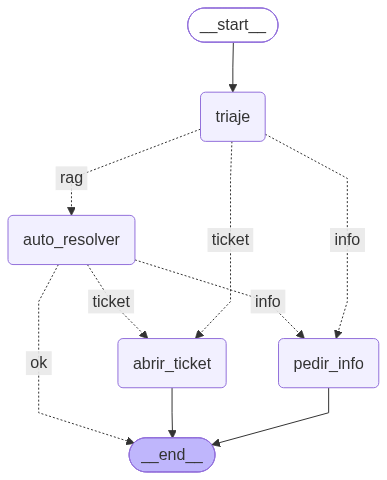

In [38]:
from IPython.display import display, Image

graph_bytes = grafo.get_graph().draw_mermaid_png()
display(Image(graph_bytes))

In [39]:
PREGUNTA = "¿tienen alguna política de rembolso?"

respuesta = grafo.invoke({"pregunta": PREGUNTA})
print("")
print(f"PREGUNTA: {PREGUNTA}")
print(f"DECISIÓN DE TRIAJE: {respuesta['triaje']['decision']} | URGENCIA: {respuesta['triaje']['urgencia']} | ACCIÓN FINAL: {respuesta['accion_final']}")
print(f"RESPUESTA: {respuesta['respuesta']}")
if respuesta['citaciones']:
  for i, citacion in enumerate(respuesta['citaciones']):
    print(f"    - CITACIÓN {i + 1}:")
    print(f"      Camino del documento: {citacion.metadata['file_path']}")
    print(f"      Contenido: {citacion.page_content.replace('\n', '')}")

Ejecutando nodo 'triaje'...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...
Decidiendo el flujo después del nodo 'auto_resolver'...
RAG con éxito, finalizando el flujo.

PREGUNTA: ¿tienen alguna política de rembolso?
DECISIÓN DE TRIAJE: AUTO_RESOLVER | URGENCIA: BAJA | ACCIÓN FINAL: AUTO_RESOLVER
RESPUESTA: Sí, tenemos una política de reembolsos y devoluciones disponible para nuestros clientes. De acuerdo con nuestra política, si un reembolso es aprobado, se realizará al mismo medio de pago original. Sin embargo, para darte información más específica sobre cómo funciona nuestro proceso de reembolsos, incluyendo los plazos y condiciones, necesitaría saber más sobre tu situación en particular, como el motivo del reembolso y el estado actual de tu orden. ¿Puedes proporcionarme más detalles sobre tu consulta o reclamo? Estoy aquí para ayudarte.


In [40]:
mensajes_de_prueba = [
	"El banco me cobró la compra en la tarjeta, pero no me llegó ningún correo de confirmación ni número de orden. Preciso respuest",
	"Intenté comprar, pero el sistema me rechaza la tarjeta todo el tiempo, ¿qué puedo hacer?",
	"Ya me aprobaron la devolución del dinero, ¿cuánto tiempo tarda en verse reflejado el reembolso?",
	"Acabo de recibir mi paquete hace dos horas, viene todo aplastado por el correo y el producto adentro está roto. necesito devolverlo",
	"Hola, envié mi postulación para el programa de afiliados hace unos días y quería saber si ya me aprobaron la cuenta.",
	"¿Qué pasa con mi comisión si un usuario compró con mi enlace de afiliado, pero luego devolvió el producto?",
	"¿Quién fue Ronaldinho Gaucho?"
]

In [41]:
for prueba in mensajes_de_prueba:
  respuesta = grafo.invoke({"pregunta": prueba})
  print("")
  print(f"PREGUNTA: {prueba}")
  print(f"DECISIÓN DE TRIAJE: {respuesta['triaje']['decision']} | URGENCIA: {respuesta['triaje']['urgencia']} | ACCIÓN FINAL: {respuesta['accion_final']}")
  print(f"RESPUESTA: {respuesta['respuesta']}")
  if respuesta['citaciones']:
    for i, citacion in enumerate(respuesta['citaciones']):
      print(f"    - CITACIÓN {i + 1}:")
      print(f"      Camino del documento: {citacion.metadata['file_path']}")
      print(f"      Contenido: {citacion.page_content.replace('\n', '')}")
  print("-----------------------------------------------")

Ejecutando nodo 'triaje'...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'pedir_info'...

PREGUNTA: El banco me cobró la compra en la tarjeta, pero no me llegó ningún correo de confirmación ni número de orden. Preciso respuest
DECISIÓN DE TRIAJE: PEDIR_INFO | URGENCIA: BAJA | ACCIÓN FINAL: PEDIR_INFO
RESPUESTA: Necesito más informaciones sobre tu pedido.
-----------------------------------------------
Ejecutando nodo 'triaje'...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'pedir_info'...

PREGUNTA: Intenté comprar, pero el sistema me rechaza la tarjeta todo el tiempo, ¿qué puedo hacer?
DECISIÓN DE TRIAJE: PEDIR_INFO | URGENCIA: BAJA | ACCIÓN FINAL: PEDIR_INFO
RESPUESTA: Necesito más informaciones sobre tu pedido.
-----------------------------------------------
Ejecutando nodo 'triaje'...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...
Decidiendo el flujo después del nodo 'auto_resolver'...
RAG con éxito, final

## Interfaz Gradio para el Agente

In [42]:
import gradio as gr

def run_agent(pregunta: str) -> str:
  """Ejecuta el agente con la pregunta dada y formatea la salida."""
  respuesta = grafo.invoke({"pregunta": pregunta})

  output_str = []
  output_str.append(f"**PREGUNTA:** {pregunta}")
  output_str.append(f"**DECISIÓN DE TRIAJE:** {respuesta['triaje']['decision']} | **URGENCIA:** {respuesta['triaje']['urgencia']} | **ACCIÓN FINAL:** {respuesta['accion_final']}")
  output_str.append(f"**RESPUESTA:** {respuesta['respuesta']}")


  return "\n".join(output_str)


# Creando la interfaz Gradio
interface = gr.Interface(
    fn=run_agent,
    inputs=gr.Textbox(lines=5, label="Ingresa tu pregunta al agente:", placeholder="Ej: ¿Cuál es su política de devoluciones?"),
    outputs=gr.Markdown(label="Respuesta del Agente"),
    title="Agente de Service Desk para E-commerce (BimBam Buy)",
    description="Este agente utiliza un sistema de triaje y RAG para responder a las consultas de los clientes."
)

# Lanzar la interfaz
interface.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f0958b95eb44d793b0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Ejecutando nodo 'triaje'...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...
Decidiendo el flujo después del nodo 'auto_resolver'...
RAG ha fallado, pediré más informaciones al usuario.
Ejecutando nodo 'pedir_info'...
Ejecutando nodo 'triaje'...
Decidiendo el flujo después del nodo 'triaje'...
Ejecutando nodo 'auto_resolver'...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 867, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 393, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2280, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1657, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 65, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

Ejecutando nodo 'triaje'...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 867, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 393, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2280, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1657, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 65, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

Ejecutando nodo 'triaje'...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 867, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 393, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2280, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1657, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 65, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://f0958b95eb44d793b0.gradio.live
